In [1]:
# importing libs 
from torchvision import datasets 
import torch 
import torch.nn as nn 
import torch.optim as optim
from matplotlib import pyplot as plt 
from torchvision import transforms 
import datetime
from collections import OrderedDict

import torch.nn.functional as F  

In [2]:
# downloading CIFAR-10 data using torchvison 
data_path = "data/"
cifar10 = datasets.CIFAR10(data_path, train=True, download=False) 
cifar10_val = datasets.CIFAR10(data_path, train=False, download=False)


In [3]:
cifar10 = datasets.CIFAR10(data_path, train=True, download=False,transform=transforms.Compose([transforms.ToTensor(), transforms.Normalize(mean=(0.4915, 0.4823, 0.4468), std=(0.247, 0.2435, 0.2616))])) 
cifar10_val = datasets.CIFAR10(data_path, train=False, download=False,transform=transforms.Compose([transforms.ToTensor(), transforms.Normalize(mean=(0.4915, 0.4823, 0.4468), std=(0.247, 0.2435, 0.2616))]))

# building data set 

# filtering the cifar10 data and remap the labels. 
label_map = {0: 0, 2: 1}
class_names = ['airplane','bird']

cifar2 = [(img, label_map[label]) for img, label in cifar10 if label in [0,2]]
cifar2_val = [(img, label_map[label]) for img, label in cifar10_val if label in [0,2]]

In [4]:
# Convlution in action 
conv = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3) 
print(conv)
print(conv.weight.shape, conv.bias.shape)

Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1))
torch.Size([16, 3, 3, 3]) torch.Size([16])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
torch.Size([1, 3, 32, 32]) torch.Size([1, 16, 30, 30])


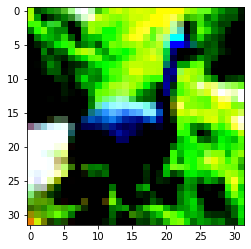

In [5]:
# passing img to conv layer 
img,_ = cifar2[0] 
output = conv(img.unsqueeze(0))

print(img.unsqueeze(0).shape, output.shape)
plt.imshow(img.permute(1,2,0), cmap="gray")

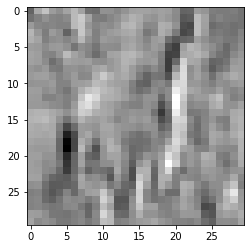

In [6]:
plt.imshow(output[0,0].detach(), cmap="gray")

torch.Size([1, 3, 32, 32]) torch.Size([1, 1, 32, 32])


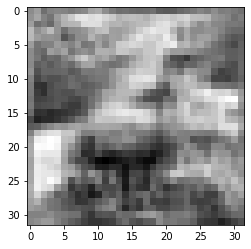

In [7]:
# adding padding to the conv layer 
conv = nn.Conv2d(in_channels=3, out_channels=1, kernel_size=3, padding=1) 
output = conv(img.unsqueeze(0)) 
print(img.unsqueeze(0).shape, output.shape)
plt.imshow(output[0,0].detach(), cmap="gray")

In [8]:
# detecting features with convolutions 
# manuallly setting weights by hand 
with torch.no_grad():
    conv.bias.zero_()
    print(conv.bias)

with torch.no_grad():
    conv.weight.fill_(1.0/9.0)
    #conv.weight.one_() # we used this which would result in each pixel in the output being the sum of the pixel in the neighborhood. 
    print(conv.weight)

Parameter containing:
tensor([0.], requires_grad=True)
Parameter containing:
tensor([[[[0.1111, 0.1111, 0.1111],
          [0.1111, 0.1111, 0.1111],
          [0.1111, 0.1111, 0.1111]],

         [[0.1111, 0.1111, 0.1111],
          [0.1111, 0.1111, 0.1111],
          [0.1111, 0.1111, 0.1111]],

         [[0.1111, 0.1111, 0.1111],
          [0.1111, 0.1111, 0.1111],
          [0.1111, 0.1111, 0.1111]]]], requires_grad=True)


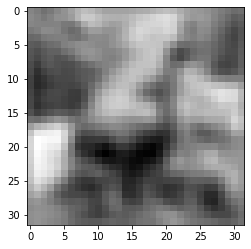

In [9]:
output = conv(img.unsqueeze(0)) 
plt.imshow(output[0,0].detach(), cmap="gray")
plt.show()

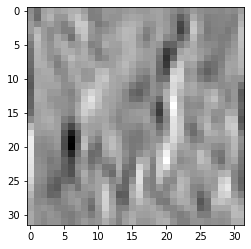

In [10]:
# trying a different approcah in filling the weight 
conv = nn.Conv2d(in_channels=3, out_channels=1, kernel_size=3, padding=1)

with torch.no_grad():
    conv.weight[:] = torch.tensor([[-1.0, 0.0, 1.0],
                                    [-1.0, 0.0, 1.0],
                                    [-1.0, 0.0, 1.0]])
    conv.bias.zero_()

output = conv(img.unsqueeze(0))
plt.imshow(output[0,0].detach(), cmap="gray")
plt.show()

In [11]:
# max pooling 
pool = nn.MaxPool2d(2)
output = pool(img.unsqueeze(0)) 
print(img.unsqueeze(0).shape, output.shape)

torch.Size([1, 3, 32, 32]) torch.Size([1, 3, 16, 16])


In [12]:
# putting it all together for the network 
model = nn.Sequential(nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1),
                        nn.Tanh(), 
                        nn.MaxPool2d(2),
                        nn.Conv2d(in_channels=16, out_channels=8, kernel_size=3, padding=1),
                        nn.Tanh(),
                        nn.MaxPool2d(2),
                        #....
                        nn.Linear(8*8*8,32),
                        nn.Tanh(),
                        nn.Linear(32,2))

# count of the number of parameters 
numel_list = [p.numel() for p in model.parameters()]
print(sum(numel_list), numel_list)

18090 [432, 16, 1152, 8, 16384, 32, 64, 2]


In [13]:
# Subclassing nn.Module 
class Net(nn.Module):
    def __init__(self):
        super().__init__() 
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1) 
        self.act = nn.Tanh() 
        self.pool_2x2 = nn.MaxPool2d(2) 
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=8, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(8*8*8,32) 
        self.fc2 = nn.Linear(32, 2)

    def forward(self, x):
        out = self.pool_2x2(self.act(self.conv1(x)))
        out = self.pool_2x2(self.act(self.conv2(out))) 
        out = out.view(-1, 8*8*8) # reshaping output to nn.linear 
        out = self.act(self.fc1(out)) 
        out = self.fc2(out)
        
        return out

model = Net()
print(model(img.unsqueeze(0)))

numel_list = [p.numel() for p in model.parameters()]
print(sum(numel_list), numel_list)

tensor([[-0.0357, -0.1200]], grad_fn=<AddmmBackward>)
18090 [432, 16, 1152, 8, 16384, 32, 64, 2]


In [14]:
# Functional API 
# using functional function to create model 

class Net(nn.Module):
    def __init__(self):
        super().__init__() 
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)  
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=8, kernel_size=3, padding=1) 
        self.fc1 = nn.Linear(8*8*8, 32) 
        self.fc2 = nn.Linear(32, 2) 
    
    def forward(self, x):
        out = F.max_pool2d(torch.tanh(self.conv1(x)), 2)
        out = F.max_pool2d(torch.tanh(self.conv2(out)), 2) 
        out = out.view(-1, 8*8*8) 
        out = torch.tanh(self.fc1(out))
        out = self.fc2(out) 
        return out 

model = Net()
print(model(img.unsqueeze(0)))


tensor([[0.0279, 0.3618]], grad_fn=<AddmmBackward>)


In [15]:
# training model 
def training_loop(n_epochs, optimizer, model, loss_fn, train_loader):
    for epoch in range(1, n_epochs+1): # we loop over the epochs number from 1 rather than 0 
        loss_train = 0.0 
        for imgs, labels in train_loader: # looping over dataset in batches created by the dataloader 
            output = model(imgs) 
            loss = loss_fn(output, labels) # computing the loss 
            optimizer.zero_grad() # zero_grad 
            loss.backward()  # performing backward to compute the grad of all params from the network
            optimizer.step()  # updating the model 

            loss_train += loss.item() 
        if epoch == 1 or epoch%10 == 0:
            print(f"{datetime.datetime.now()} Epoch {epoch}, Training loss {loss_train/len(train_loader)}")
        
        

In [16]:
# validate model 
def validate(model, train_loader, val_loader):
    accdict = {}
    for name, loader in [("train", train_loader), ("val", val_loader)]:
        correct = 0 
        total = 0 

        with torch.no_grad():
            for imgs, labels in loader:
                outputs = model(imgs) 
                _, predicted = torch.max(outputs, dim=1) 
                total += labels.shape[0] 
                correct += int((predicted == labels).sum())
        print(f"Accuracy {name}: {round((correct/total),2)}")
        accdict[name] = correct / total
    return accdict



In [17]:
# Training model 

# creating data loader  for training
train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64, shuffle=True) 
val_loader = torch.utils.data.DataLoader(cifar2_val, batch_size=64, shuffle=False)


# creating model 
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=8, kernel_size=3, padding=1) 
        self.fc1 = nn.Linear(8 * 8 * 8, 32)
        self.fc2 = nn.Linear(32, 2) 
    
    def forward(self, x):
        out = F.max_pool2d(torch.relu(self.conv1(x)), 2) 
        out = F.max_pool2d(torch.relu(self.conv2(out)), 2)
        out = out.view(-1, 8 * 8 * 8) 
        out = torch.tanh(self.fc1(out)) 
        out = self.fc2(out)
        return out 

model = Net() 
learning_rate = 1e-3 
optimizer = optim.SGD(model.parameters(), lr=learning_rate) 
loss_fn = nn.CrossEntropyLoss() 

training_loop(n_epochs=100, optimizer=optimizer, model=model, loss_fn=loss_fn, train_loader=train_loader,)

all_acc_dict = OrderedDict()

# creating data loader  for validation
train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64, shuffle=False) 
val_loader = torch.utils.data.DataLoader(cifar2_val, batch_size=64, shuffle=False)
all_acc_dict["basline"] = validate(model=model, train_loader=train_loader, val_loader=val_loader)

2020-08-25 16:25:30.458813 Epoch 1, Training loss 0.6862783067545314
2020-08-25 16:25:46.926422 Epoch 10, Training loss 0.5736717786758568
2020-08-25 16:26:05.873581 Epoch 20, Training loss 0.4897413221514149
2020-08-25 16:26:25.209089 Epoch 30, Training loss 0.4490291415506108
2020-08-25 16:26:43.966542 Epoch 40, Training loss 0.4053920682068843
2020-08-25 16:27:03.579343 Epoch 50, Training loss 0.37195057720895025
2020-08-25 16:27:22.484479 Epoch 60, Training loss 0.35695446610071097
2020-08-25 16:27:42.394330 Epoch 70, Training loss 0.346744137869519
2020-08-25 16:28:03.431364 Epoch 80, Training loss 0.3386959249426605
2020-08-25 16:28:22.565566 Epoch 90, Training loss 0.32958043741572435
2020-08-25 16:28:41.737022 Epoch 100, Training loss 0.3227839414860792
Accuracy train: 0.86
Accuracy val: 0.85


In [18]:
# saving and loading model
torch.save(model.state_dict(), data_path + "birds_vs_airplanes.pt") # saving model 

loaded_model = Net() # initializing model 
loaded_model.load_state_dict(torch.load(data_path + "birds_vs_airplanes.pt")) # loading model 

<All keys matched successfully>

In [19]:
# Training on GPU 
"""
We use to .to function in the nn.Module to move all params to GPU. 
we use torch.cuda.is_available to check if GPU is available 
"""
device = (torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu"))
print(f"Training on device {device}.")


# modifying training_loop function to train on device 
def training_loop(n_epochs, optimizer, model, loss_fn, train_loader, device):
    for epoch in range(1, n_epochs+1):
        loss_train = 0.0 
        for imgs, labels in train_loader:
            imgs = imgs.to(device=device)
            labels = labels.to(device=device) 
            outputs = model(imgs) 
            loss = loss_fn(outputs, labels)  

            optimizer.zero_grad()
            loss.backward()
            optimizer.step() 

            loss_train += loss.item()
    
        if epoch == 1 or epoch % 10 == 0:
            print(f"{datetime.datetime.now()} Epoch {epoch}, Training loss {round(loss_train/len(train_loader),4)}")


# creating data loader  for training
train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64, shuffle=True) 
val_loader = torch.utils.data.DataLoader(cifar2_val, batch_size=64, shuffle=False)


model = Net().to(device=device)
learning_rate = 1e-2
optimizer = optim.SGD(model.parameters(), lr=learning_rate)
loss_fn = nn.CrossEntropyLoss() 

training_loop(n_epochs=100, optimizer=optimizer, model=model, loss_fn=loss_fn, train_loader=train_loader, device=device)
all_acc_dict["basline_device"] = validate(model=model, train_loader=train_loader, val_loader=val_loader)

Training on device cpu.
2020-08-25 16:28:45.273865 Epoch 1, Training loss 0.6131
2020-08-25 16:29:03.468576 Epoch 10, Training loss 0.3288
2020-08-25 16:29:24.638418 Epoch 20, Training loss 0.2865
2020-08-25 16:29:45.605500 Epoch 30, Training loss 0.2598
2020-08-25 16:30:08.323207 Epoch 40, Training loss 0.2357
2020-08-25 16:30:30.356450 Epoch 50, Training loss 0.2089
2020-08-25 16:30:55.459590 Epoch 60, Training loss 0.186
2020-08-25 16:31:20.177809 Epoch 70, Training loss 0.1595
2020-08-25 16:31:43.747516 Epoch 80, Training loss 0.1378
2020-08-25 16:32:05.938310 Epoch 90, Training loss 0.1136
2020-08-25 16:32:30.460445 Epoch 100, Training loss 0.0926
Accuracy train: 0.97
Accuracy val: 0.9


In [20]:
# saving model 
torch.save(model.state_dict(), data_path + "birds_vs_airplanes_device.pt") 

"""
There is a slight complication when loading network weights: PyTorch will attempt
to load the weight to the same device it was saved from—that is, weights on the GPU
will be restored to the GPU.
"""
loaded_model = Net().to(device=device) 
loaded_model.load_state_dict(torch.load(data_path + "birds_vs_airplanes_device.pt", map_location=device))  # loading model back 

<All keys matched successfully>

In [22]:
# validate model 
def validate(model, train_loader, val_loader):
    accdict = {}
    for name, loader in [("train", train_loader), ("val", val_loader)]:
        correct = 0 
        total = 0 

        with torch.no_grad():
            for imgs, labels in loader:
                imgs = imgs.to(device=device)
                labels = labels.to(device=device)
                outputs = model(imgs) 
                _, predicted = torch.max(outputs, dim=1) 
                total += labels.shape[0] 
                correct += int((predicted == labels).sum())
        print(f"Accuracy {name}: {round((correct/total),2)}")
        accdict[name] = correct / total
    return accdict

In [23]:
# Model Design 
## Adding memory capacity: Width 
"""
The width of the netowrk: the number of neurons per layer or channels per convolution.  To make a module wider, we just need to specify a large number of output channel in the first convolution and increase the subsequent layers accordly. 
Eg. below 
"""
class NetWidth(nn.Module):
    def __init__(self, n_channels=32):
        super().__init__() 
        self.n_channels = n_channels
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=n_channels, kernel_size=3, padding=1) 
        self.conv2 = nn.Conv2d(in_channels=n_channels, out_channels=n_channels // 2, kernel_size=3, padding=1) 
        self.fc1 = nn.Linear(n_channels // 2 * 8 * 8, n_channels)
        self.fc2 = nn.Linear(n_channels, 2)

    def forward(self, x):
        out = F.max_pool2d(torch.tanh(self.conv1(x)),2) 
        out = F.max_pool2d(torch.tanh(self.conv2(out)), 2) 
        out = out.view(-1, self.n_channels//2 * 8 * 8)
        out = torch.tanh(self.fc1(out)) 
        out = self.fc2(out) 
        return out 


model = NetWidth(n_channels=64)

# creating data loader  for training
train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64, shuffle=True) 
val_loader = torch.utils.data.DataLoader(cifar2_val, batch_size=64, shuffle=False)

learning_rate = 1e-2
optimizer = optim.SGD(model.parameters(), lr=learning_rate)
loss_fn = nn.CrossEntropyLoss() 

device = (torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu"))
print(f"Training on device {device}.")

training_loop(n_epochs=100, optimizer=optimizer, model=model, loss_fn=loss_fn, train_loader=train_loader, device=device)
all_acc_dict["width_64"] = validate(model=model, train_loader=train_loader, val_loader=val_loader)


Training on device cpu.
2020-08-25 16:33:38.671929 Epoch 1, Training loss 0.5073
2020-08-25 16:35:17.363932 Epoch 10, Training loss 0.2955
2020-08-25 16:36:52.546169 Epoch 20, Training loss 0.2501
2020-08-25 16:38:27.115299 Epoch 30, Training loss 0.2093
2020-08-25 16:40:05.868769 Epoch 40, Training loss 0.1769
2020-08-25 16:41:36.468926 Epoch 50, Training loss 0.1491
2020-08-25 16:43:15.014451 Epoch 60, Training loss 0.1141
2020-08-25 16:45:01.444191 Epoch 70, Training loss 0.0866
2020-08-25 16:46:44.126438 Epoch 80, Training loss 0.0648
2020-08-25 16:48:35.663171 Epoch 90, Training loss 0.0461
2020-08-25 16:50:16.035554 Epoch 100, Training loss 0.0323
Accuracy train: 0.99
Accuracy val: 0.9


In [24]:
# adding L2 regularization to training_loop fxn 
def training_loop_l2reg(n_epochs, optimizer, model, loss_fn, train_loader, device):
    for epoch in range(1, n_epochs+1):
        loss_train = 0.0
        
        for imgs, labels in train_loader:
            # converting images to device available 
            imgs = imgs.to(device=device)
            labels = labels.to(device=device) 
            # optimization 
            outputs = model(imgs)
            loss = loss_fn(outputs, labels)
            # regularization 
            l2_lambda = 0.001
            l2_norm = sum(p.pow(2.0).sum() for p in model.parameters()) 
            # updating loss  
            loss = loss +  l2_lambda * l2_norm

            optimizer.zero_grad() 
            loss.backward() 
            optimizer.step() 

            loss_train += loss.item() 
        if epoch == 1 or epoch % 10 == 0:
            print(f"{datetime.datetime.now()} Epoch {epoch}, Training loss {round(loss_train/len(train_loader),4)}")
            


model = NetWidth(n_channels=32)
learning_rate = 1e-2
optimizer = optim.SGD(model.parameters(), lr=learning_rate)
loss_fn = nn.CrossEntropyLoss() 

device = (torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu"))
print(f"Training on device {device}.")

training_loop_l2reg(n_epochs=100, optimizer=optimizer, model=model, loss_fn=loss_fn, train_loader=train_loader, device=device)

train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64, shuffle=False) 
val_loader = torch.utils.data.DataLoader(cifar2_val, batch_size=64, shuffle=False)

all_acc_dict["l2 reg"] = validate(model=model, train_loader=train_loader, val_loader=val_loader)


Training on device cpu.
2020-08-25 16:50:27.340492 Epoch 1, Training loss 0.5743
2020-08-25 16:51:15.691562 Epoch 10, Training loss 0.3415
2020-08-25 16:52:10.624388 Epoch 20, Training loss 0.3027
2020-08-25 16:53:49.087001 Epoch 30, Training loss 0.273
2020-08-25 16:55:15.608861 Epoch 40, Training loss 0.2493
2020-08-25 16:56:12.216448 Epoch 50, Training loss 0.2307
2020-08-25 16:57:06.894708 Epoch 60, Training loss 0.2145
2020-08-25 16:57:59.781862 Epoch 70, Training loss 0.2011
2020-08-25 16:59:07.074943 Epoch 80, Training loss 0.1883
2020-08-25 16:59:54.883387 Epoch 90, Training loss 0.1741
2020-08-25 17:00:36.766827 Epoch 100, Training loss 0.1641
Accuracy train: 0.96
Accuracy val: 0.9


In [25]:
def training_loop_l1_reg(n_epochs, optimizer, model, loss_fn, train_loader, device):
    for epoch in range(1, n_epochs+1):

        loss_train = 0.0
        for imgs, labels in train_loader:
            # converting imgs to the device available
            imgs = imgs.to(device=device)
            labels = labels.to(device=device) 
            # optimization
            outputs = model(imgs) 
            loss = loss_fn(outputs, labels)
            # regularization 
            l1_lambda = 0.001
            l1_norm = sum(p.abs().sum() for p in model.parameters())
            # upadating loss 
            loss = loss + l1_lambda * l1_norm

            optimizer.zero_grad() 
            loss.backward() 
            optimizer.step() 

            loss_train += loss.item() 
        if epoch == 1 or epoch % 10 == 0:
            print(f"{datetime.datetime.now()} Epoch {epoch}, Training loss {round(loss_train/len(train_loader),4)}")



model = NetWidth(n_channels=64)
learning_rate = 1e-2
optimizer = optim.SGD(model.parameters(), lr=learning_rate)
loss_fn = nn.CrossEntropyLoss() 

device = (torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu"))
print(f"Training on device {device}.")

train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64, shuffle=True) 
val_loader = torch.utils.data.DataLoader(cifar2_val, batch_size=64, shuffle=False)
training_loop_l1_reg(n_epochs=100, optimizer=optimizer, model=model, loss_fn=loss_fn, train_loader=train_loader, device=device)

train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64, shuffle=False) 

all_acc_dict["l1 reg"] = validate(model=model, train_loader=train_loader, val_loader=val_loader)




Training on device cpu.
2020-08-25 17:01:15.533658 Epoch 1, Training loss 2.4216
2020-08-25 17:02:39.171419 Epoch 10, Training loss 0.8829
2020-08-25 17:04:22.469841 Epoch 20, Training loss 0.5864
2020-08-25 17:06:07.960795 Epoch 30, Training loss 0.5107
2020-08-25 17:08:00.231154 Epoch 40, Training loss 0.4695
2020-08-25 17:09:55.383290 Epoch 50, Training loss 0.4435
2020-08-25 17:11:32.065831 Epoch 60, Training loss 0.4247
2020-08-25 17:13:00.470338 Epoch 70, Training loss 0.4073
2020-08-25 17:14:35.604227 Epoch 80, Training loss 0.3909
2020-08-25 17:16:26.085524 Epoch 90, Training loss 0.3795
2020-08-25 17:18:07.286580 Epoch 100, Training loss 0.3685
Accuracy train: 0.87
Accuracy val: 0.86


In [26]:
# Model with dropout 
class NetDropout(nn.Module):
    def __init__(self, n_channels=32):
        super().__init__() 
        self.n_channels = n_channels
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=n_channels, kernel_size=3, padding=1)
        self.dropout1 = nn.Dropout2d(p=0.4) 
        self.conv2 = nn.Conv2d(in_channels=n_channels, out_channels=n_channels // 2, kernel_size=3, padding=1)
        self.dropout2 = nn.Dropout2d(p=0.4)
        self.fc1 = nn.Linear(n_channels // 2 * 8 * 8, n_channels)
        self.fc2 = nn.Linear(n_channels, 2)
    
    def forward(self, x):
        out = F.max_pool2d(torch.tanh(self.conv1(x)), 2) 
        out = self.dropout1(out)
        out = F.max_pool2d(torch.tanh(self.conv2(out)), 2)
        out = self.dropout2(out)
        out = out.view(-1, self.n_channels // 2 * 8 * 8)
        out = torch.tanh(self.fc1(out))
        out = self.fc2(out)
        return out 

model = NetDropout(n_channels=64)
learning_rate = 1e-2
optimizer = optim.SGD(model.parameters(), lr=learning_rate)
loss_fn = nn.CrossEntropyLoss() 

device = (torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu"))
print(f"Training on device {device}.")

train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64, shuffle=True) 
val_loader = torch.utils.data.DataLoader(cifar2_val, batch_size=64, shuffle=False)
training_loop(n_epochs=100, optimizer=optimizer, model=model, loss_fn=loss_fn, train_loader=train_loader, device=device)

train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64, shuffle=False) 

all_acc_dict["dropout"] = validate(model=model, train_loader=train_loader, val_loader=val_loader)



Training on device cpu.
2020-08-25 17:18:25.676683 Epoch 1, Training loss 0.5379
2020-08-25 17:20:07.938770 Epoch 10, Training loss 0.3548
2020-08-25 17:22:05.464227 Epoch 20, Training loss 0.3232
2020-08-25 17:23:52.375926 Epoch 30, Training loss 0.2992
2020-08-25 17:25:30.334121 Epoch 40, Training loss 0.2722
2020-08-25 17:27:01.762520 Epoch 50, Training loss 0.2524
2020-08-25 17:28:33.219290 Epoch 60, Training loss 0.2323
2020-08-25 17:30:24.160003 Epoch 70, Training loss 0.2159
2020-08-25 17:32:10.086263 Epoch 80, Training loss 0.2015
2020-08-25 17:34:02.794804 Epoch 90, Training loss 0.1865
2020-08-25 17:35:51.254793 Epoch 100, Training loss 0.1711
Accuracy train: 0.93
Accuracy val: 0.88


In [28]:
# model with Batch Normalization 
class NetBatchNorm(nn.Module):
    def __init__(self, n_channels=32):
        super().__init__()
        self.n_channels = n_channels 
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=n_channels, kernel_size=3, padding=1) 
        self.batch_norm1 = nn.BatchNorm2d(num_features=n_channels)
        self.conv2 = nn.Conv2d(in_channels=n_channels, out_channels=n_channels//2, kernel_size=3, padding=1)
        self.batch_norm2 = nn.BatchNorm2d(num_features=n_channels // 2)
        self.fc1 = nn.Linear(n_channels // 2 * 8 * 8, n_channels) 
        self.fc2 = nn.Linear(n_channels, 2) 

    def forward(self, x):
        out = self.batch_norm1(self.conv1(x)) 
        out = F.max_pool2d(torch.tanh(out), 2) 
        out = self.batch_norm2(self.conv2(out))
        out = F.max_pool2d(torch.tanh(out), 2)
        out = out.view(-1, self.n_channels // 2 * 8 * 8)
        out = torch.tanh(self.fc1(out)) 
        out = self.fc2(out) 
        return out 


model = NetBatchNorm(n_channels=64)
learning_rate = 1e-2
optimizer = optim.SGD(model.parameters(), lr=learning_rate)
loss_fn = nn.CrossEntropyLoss() 

device = (torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu"))
print(f"Training on device {device}.")

train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64, shuffle=True) 
val_loader = torch.utils.data.DataLoader(cifar2_val, batch_size=64, shuffle=False)
training_loop(n_epochs=100, optimizer=optimizer, model=model, loss_fn=loss_fn, train_loader=train_loader, device=device)

train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64, shuffle=False) 

all_acc_dict["batch_norm"] = validate(model=model, train_loader=train_loader, val_loader=val_loader)

Training on device cpu.
2020-08-25 17:36:12.631625 Epoch 1, Training loss 0.4223
2020-08-25 17:38:15.843714 Epoch 10, Training loss 0.2399
2020-08-25 17:40:32.614895 Epoch 20, Training loss 0.1665
2020-08-25 17:42:40.301916 Epoch 30, Training loss 0.109
2020-08-25 17:44:47.624608 Epoch 40, Training loss 0.0661
2020-08-25 17:46:57.061183 Epoch 50, Training loss 0.0348
2020-08-25 17:49:20.771559 Epoch 60, Training loss 0.0159
2020-08-25 17:51:27.564261 Epoch 70, Training loss 0.0506
2020-08-25 17:53:25.226885 Epoch 80, Training loss 0.0049
2020-08-25 17:55:36.096597 Epoch 90, Training loss 0.003
2020-08-25 17:57:48.853962 Epoch 100, Training loss 0.0035
Accuracy train: 1.0
Accuracy val: 0.9


In [29]:
all_acc_dict

OrderedDict([('basline', {'train': 0.8614, 'val': 0.8515}),
             ('basline_device', {'train': 0.9732, 'val': 0.895}),
             ('width_64', {'train': 0.989, 'val': 0.895}),
             ('l2 reg', {'train': 0.9557, 'val': 0.8995}),
             ('l1 reg', {'train': 0.8714, 'val': 0.8565}),
             ('dropout', {'train': 0.9342, 'val': 0.8805}),
             ('batch_norm', {'train': 1.0, 'val': 0.8955})])

In [ ]:
# model with Depth module using RELU 
class NetDepth(nn.Module):
    def __init__(self, n_channels=32):
        super().__init__()
        self.n_channels = n_channels
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=n_channels, kernel_size=3, padding=1) 
        self.conv2 = nn.Conv2d(in_channels=n_channels, out_channels=n_channels // 2, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=n_channels//2, out_channels=n_channels//2, kernel_size=3, padding=1) 
        self.fc1 = nn.Linear(4 * 4 * n_channels // 2, n_channels)
        self.fc2 = nn.Linear(n_channels, 2)

    def forward(self, x):
        out = F.max_pool2d(torch.relu(self.conv1(x)), 2) 
        out = F.max_pool2d(torch.relu(self.conv2(out)), 2) 
        out = F.max_pool2d(torch.relu(self.conv3(out)), 2)
        out = out.view(-1, 4 * 4 * self.n_channels // 2)
        out = torch.relu(self.fc1(out))
        out = self.fc2(out)
        return out

model = NetDepth(n_channels=64)
learning_rate = 1e-2
optimizer = optim.SGD(model.parameters(), lr=learning_rate)
loss_fn = nn.CrossEntropyLoss() 

device = (torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu"))
print(f"Training on device {device}.")

train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64, shuffle=True) 
val_loader = torch.utils.data.DataLoader(cifar2_val, batch_size=64, shuffle=False)
training_loop(n_epochs=100, optimizer=optimizer, model=model, loss_fn=loss_fn, train_loader=train_loader, device=device)

train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64, shuffle=False) 

all_acc_dict["Depth"] = validate(model=model, train_loader=train_loader, val_loader=val_loader)

In [ ]:
# ResNet model with skip connection
class NetRes(nn.Module):
    def __init__(self, n_channels=32):
        super().__init__()
        self.n_channels = n_channels
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=n_channels, kernel_size=3, padding=1) 
        self.conv2 = nn.Conv2d(in_channels=n_channels, out_channels=n_channels // 2, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=n_channels//2, out_channels=n_channels//2, kernel_size=3, padding=1) 
        self.fc1 = nn.Linear(4 * 4 * n_channels // 2, n_channels)
        self.fc2 = nn.Linear(n_channels, 2)

    def forward(self, x):
        out = F.max_pool2d(torch.relu(self.conv1(x)), 2) 
        out = F.max_pool2d(torch.relu(self.conv2(out)), 2) 
        out1 = out 
        out = F.max_pool2d(torch.relu(self.conv3(out)) + out1, 2) # skip connection
        out = out.view(-1, 4 * 4 * self.n_channels // 2)
        out = torch.relu(self.fc1(out))
        out = self.fc2(out)
        return out

model = NetRes(n_channels=64)
learning_rate = 1e-2
optimizer = optim.SGD(model.parameters(), lr=learning_rate)
loss_fn = nn.CrossEntropyLoss() 

device = (torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu"))
print(f"Training on device {device}.")

train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64, shuffle=True) 
val_loader = torch.utils.data.DataLoader(cifar2_val, batch_size=64, shuffle=False)
training_loop(n_epochs=100, optimizer=optimizer, model=model, loss_fn=loss_fn, train_loader=train_loader, device=device)

train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64, shuffle=False) 

all_acc_dict["Depth"] = validate(model=model, train_loader=train_loader, val_loader=val_loader)

In [ ]:
# Creating Resnet block and ResNet deep model 

class ResBlock(nn.Module):
    def __init__(self, n_channls):
        super(ResBlock, self).__init__()
        self.conv = nn.Conv2d(in_channels=n_channls, out_channels=n_channls, kernel_size=3, padding=1, bias=False) #BatchNorm layer cancel the effect of bias so its left out. 
        self.batch_norm = nn.BatchNorm2d(num_features=n_channls)
        torch.nn.init.kaiming_normal_(self.conv.weight, nonlinearity='relu') 
        torch.nn.init.constant_(self.batch_norm.weight, 0.5)
        torch.nn.init.zeros_(self.batch_norm.bias) 

    def forward(self, x):
        out = self.conv(x)
        out = self.batch_norm(out)
        out = torch.relu(out) 
        return out + x


class NetResDeep(nn.Module):
    def __init__(self, n_channels=32, n_blocks=10):
        super(NetResDeep, self).__init__()
        self.n_channels = n_channels
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=n_channels, kernel_size=3, padding=1)
        self.resblocks = nn.Sequential(*(n_blocks * [ResBlock(n_channls=n_channels)]))
        self.fc1 = nn.Linear(8 * 8 * n_channels, n_channels)
        self.fc2 = nn.Linear(n_channels, 2)
    
    def forward(self, x):
        out = F.max_pool2d(torch.relu(self.conv1(x)),2)
        out = self.resblocks(out)
        out = F.max_pool2d(out, 2)
        out = out.view(-1, self.n_channels * 8 * 8)
        out = torch.relu(self.fc1(out))
        out = self.fc2(out)
        return out 


        

model = NetResDeep(n_channels=64).to(device=device)
learning_rate = 1e-2
optimizer = optim.SGD(model.parameters(), lr=learning_rate)
loss_fn = nn.CrossEntropyLoss() 

device = (torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu"))
print(f"Training on device {device}.")

train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64, shuffle=True) 
val_loader = torch.utils.data.DataLoader(cifar2_val, batch_size=64, shuffle=False)
training_loop(n_epochs=100, optimizer=optimizer, model=model, loss_fn=loss_fn, train_loader=train_loader, device=device)

train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64, shuffle=False) 

all_acc_dict["ResDeep"] = validate(model=model, train_loader=train_loader, val_loader=val_loader)

In [ ]:
model = NetResDeep(n_channels=64).to(device=device)
learning_rate = 3e-3
optimizer = optim.SGD(model.parameters(), lr=learning_rate)
loss_fn = nn.CrossEntropyLoss() 

device = (torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu"))
print(f"Training on device {device}.")

train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64, shuffle=True) 
val_loader = torch.utils.data.DataLoader(cifar2_val, batch_size=64, shuffle=False)
training_loop(n_epochs=100, optimizer=optimizer, model=model, loss_fn=loss_fn, train_loader=train_loader, device=device)

train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64, shuffle=False) 

all_acc_dict["ResDeep_new_learning_rate"] = validate(model=model, train_loader=train_loader, val_loader=val_loader)